# Preprocessing Case Study: Spaceship Maintenance Prediction

## Problem Statement

You have been hired as a Data Scientist for a galactic transportation company. Your task is to build a machine learning model to predict whether a spaceship requires maintenance based on sensor data and operational logs.

However, the raw data collected from the ships is messy. It contains missing values, categorical variables, features on different scales, and some irrelevant information. 

**Your Goal**: Apply the preprocessing techniques you have learned (cleaning, standardization, feature engineering, and feature selection) to prepare this dataset for modeling.

### Learning Objectives
- **Data Cleaning**: Handle missing data appropriately.
- **Standardization**: Scale numerical features to a common range.
- **Feature Engineering**: Create new meaningful features from raw data.
- **Feature Selection**: Identify and keep only the most relevant features.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load spaceship dataset


In [3]:
df = pd.read_csv('./spaceship_data.csv')

## 2. Exploratory Data Analysis (EDA)

Before preprocessing, it's crucial to understand the data structure, types, and summary statistics.

In [4]:
# TODO: Check the shape of the dataset
# TODO: Check data types and missing values info
# TODO: Get summary statistics (mean, min, max, etc.)
df.shape

(10000, 8)

In [8]:
df.dtypes

Ship_ID                object
Sensor_Alpha          float64
Sensor_Beta           float64
Zone                   object
Last_Service_Date      object
Error_Log              object
Random_Noise          float64
Maintenance_Needed      int64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ship_ID             10000 non-null  object 
 1   Sensor_Alpha        9951 non-null   float64
 2   Sensor_Beta         10000 non-null  float64
 3   Zone                9970 non-null   object 
 4   Last_Service_Date   10000 non-null  object 
 5   Error_Log           4018 non-null   object 
 6   Random_Noise        10000 non-null  float64
 7   Maintenance_Needed  10000 non-null  int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 625.1+ KB


In [7]:
df.isnull().sum()

Ship_ID                  0
Sensor_Alpha            49
Sensor_Beta              0
Zone                    30
Last_Service_Date        0
Error_Log             5982
Random_Noise             0
Maintenance_Needed       0
dtype: int64

In [10]:
df.describe()

,Sensor_Alpha,Sensor_Beta,Random_Noise,Maintenance_Needed
count,9951.000000,10000.000000,10000.000000,10000.000000
mean,50.274420,983.855151,0.503496,0.499200
std,14.295055,1002.641139,0.289648,0.500024
min,14.697302,0.087068,0.000035,0.000000
25%,43.406262,275.696984,0.252419,0.000000
50%,50.073848,671.948869,0.501638,0.000000
75%,56.736251,1369.260572,0.754277,1.000000
max,500.000000,10126.131872,0.999979,1.000000


In [18]:
df.head(20)

,Ship_ID,Sensor_Alpha,Sensor_Beta,Zone,Last_Service_Date,Error_Log,Random_Noise,Maintenance_Needed
0,SHP-0000,48.377316,601.865495,Sector_D,2024-05-15,Error: Pressure Drop,0.438204,0
1,SHP-0001,51.940582,5028.510376,Sector_A,2024-08-31,Error: Pressure Drop,0.685428,1
2,SHP-0002,56.732696,972.358221,Sector_D,2024-05-10,NaN,0.090055,1
3,SHP-0003,38.141834,2087.746686,Sector_B,2024-07-04,Warning: High Temp,0.929093,0
4,SHP-0004,47.703003,1215.807010,Sector_D,2024-06-20,Warning: High Temp,0.589060,1
5,SHP-0005,58.231490,208.358402,Sector_A,2024-05-04,NaN,0.219882,1
6,SHP-0006,70.146574,1233.803616,Sector_D,2024-07-15,NaN,0.734145,1
7,SHP-0007,57.464874,281.127240,Sector_C,2024-02-22,NaN,0.149852,0
8,SHP-0008,52.826205,520.653912,Sector_C,2024-12-20,Error: Pressure Drop,0.158564,1
9,SHP-0009,40.418064,317.215987,Sector_C,2024-12-27,NaN,0.390822,0


---

## 3. Data Cleaning

Your dataset contains missing values and potential outliers. Dealing with these is the first step in preprocessing.

**Guidance:**
- Check which columns have null values.
- Decide on a strategy: Drop the rows/columns? Impute with mean/median/mode?
- Consider the nature of the data (e.g., Categorical vs Numerical) when imputing.
- Identify outliers (e.g., using boxplots or statistical summaries) and decide how to handle them.

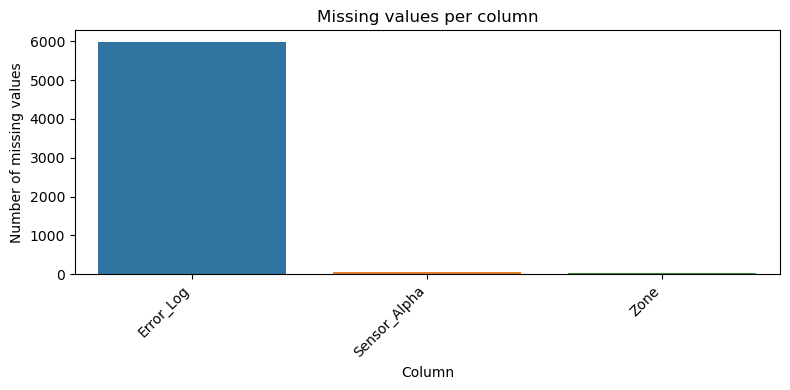

In [23]:
# TODO: Visualize missing values (optional)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing
plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, hue=missing.index)
plt.title("Missing values per column")
plt.ylabel("Number of missing values")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# TODO: Handle missing values in 'Sensor_Alpha' and 'Zone'
df['Sensor_Alpha'] = df['Sensor_Alpha'].fillna(df['Sensor_Alpha'].median())
df['Zone'] = df['Zone'].fillna('Unknown')



In [36]:
df['Error_Log'].unique()

array(['Error: Pressure Drop', nan, 'Warning: High Temp'], dtype=object)

In [34]:
df[df['Error_Log']=='Error: Pressure Drop'].count()

Ship_ID               2036
Sensor_Alpha          2036
Sensor_Beta           2036
Zone                  2036
Last_Service_Date     2036
Error_Log             2036
Random_Noise          2036
Maintenance_Needed    2036
dtype: int64

In [38]:
df[df['Error_Log']=='Warning: High Temp'].count()

Ship_ID               1982
Sensor_Alpha          1982
Sensor_Beta           1982
Zone                  1982
Last_Service_Date     1982
Error_Log             1982
Random_Noise          1982
Maintenance_Needed    1982
dtype: int64

### Despite having more than 50% missing values the 'Error_Log' column only contains 2 unique non-null values, and these values consist the rest of the non-null values. Dropping this might hide some insight. Therefore we are going to fill null with Unknown

In [39]:
df['Error_Log'] = df['Error_Log'].fillna('Unknown')

In [40]:
# TODO: Check for duplicates and remove if any
df.duplicated().sum()

np.int64(0)

In [41]:
df.isnull().sum() #verify data cleaning results

Ship_ID               0
Sensor_Alpha          0
Sensor_Beta           0
Zone                  0
Last_Service_Date     0
Error_Log             0
Random_Noise          0
Maintenance_Needed    0
dtype: int64

---

## 4. Standardization

Machine learning models often perform better when numerical input variables are scaled to a standard range. 
Look at `Sensor_Alpha` and `Sensor_Beta`. They likely have very different ranges.

**Guidance:**
- Compare the distributions of numerical features.
- Choose a scaling method: Standardization (Z-score) or Normalization (Min-Max)?
- Apply the scaling to the numerical columns.

In [44]:
# TODO: specific numerical columns to scale
num_cols = ['Sensor_Alpha', 'Sensor_Beta']
# TODO: Apply Standardization or Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].describe()

,Sensor_Alpha,Sensor_Beta
count,1.000000e+04,1.000000e+04
mean,-2.557954e-17,-1.595168e-16
std,1.000050e+00,1.000050e+00
min,-2.494946e+00,-9.812257e-01
25%,-4.773051e-01,-7.063281e-01
50%,-1.399716e-02,-3.111002e-01
75%,4.516010e-01,3.844094e-01
max,3.153922e+01,9.118650e+00


---

## 5. Feature Engineering
Raw data often needs to be transformed to be useful. 
- Dates (`Last_Service_Date`) aren't directly usable by most models.
- Categorical variables (`Zone`, `Error_Log`) need to be encoded.

**Guidance:**
- **Date features**: Extract useful components like Year, Month, or "Days since last service".
- **Text features**: Can you extract something from `Error_Log`? Maybe a binary flag for "Has Error"?
- **Categorical Encoding**: Convert `Zone` into numerical format (One-Hot Encoding or Label Encoding).

In [49]:
# TODO: Feature Engineering on 'Last_Service_Date'
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
ref_date = df['Last_Service_Date'].max()
df['Days_Since_Service'] = (ref_date - df['Last_Service_Date']).dt.days
df['Service_Month'] = df['Last_Service_Date'].dt.month
# TODO: Feature Engineering on 'Error_Log'
df['Has_Error'] = (df['Error_Log'] != 'Unknown').astype(int)
# TODO: Encode Categorical Variable 'Zone'
zone_dummies = pd.get_dummies(df['Zone'], prefix='Zone', dtype=int)
df = pd.concat([df, zone_dummies], axis=1)

In [50]:
df

,Ship_ID,Sensor_Alpha,Sensor_Beta,Zone,Last_Service_Date,Error_Log,Random_Noise,Maintenance_Needed,Days_Since_Service,Service_Month,Has_Error,Zone_Sector_A,Zone_Sector_B,Zone_Sector_C,Zone_Sector_D,Zone_Unknown
0,SHP-0000,-0.132975,-0.381002,Sector_D,2024-05-15,Error: Pressure Drop,0.438204,0,231,5,1,0,0,0,1,0
1,SHP-0001,0.116916,4.034203,Sector_A,2024-08-31,Error: Pressure Drop,0.685428,1,123,8,1,1,0,0,0,0
2,SHP-0002,0.452986,-0.011467,Sector_D,2024-05-10,Unknown,0.090055,1,236,5,0,0,0,0,1,0
3,SHP-0003,-0.850787,1.101039,Sector_B,2024-07-04,Warning: High Temp,0.929093,0,181,7,1,0,1,0,0,0
4,SHP-0004,-0.180264,0.231352,Sector_D,2024-06-20,Warning: High Temp,0.589060,1,195,6,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SHP-9995,1.124551,-0.742720,Sector_D,2024-07-14,Unknown,0.206735,1,171,7,0,0,0,0,1,0
9996,SHP-9996,-0.101810,0.068167,Sector_A,2024-11-24,Unknown,0.930893,0,38,11,0,1,0,0,0,0
9997,SHP-9997,-0.233050,0.356948,Sector_C,2024-03-23,Unknown,0.119754,1,284,3,0,0,0,1,0,0
9998,SHP-9998,-0.096340,-0.159970,Sector_A,2024-05-30,Unknown,0.719697,1,216,5,0,1,0,0,0,0


---

## 6. Feature Selection

Not all features are useful. Some might be redundant, noisy, or irrelevant (like `Ship_ID` or `Random_Noise`).

**Guidance:**
- Identifying irrelevant features (IDs, high cardinality, or purely random).
- Check for correlation between features. Highly correlated features might be redundant.
- Select the final set of features for the model.

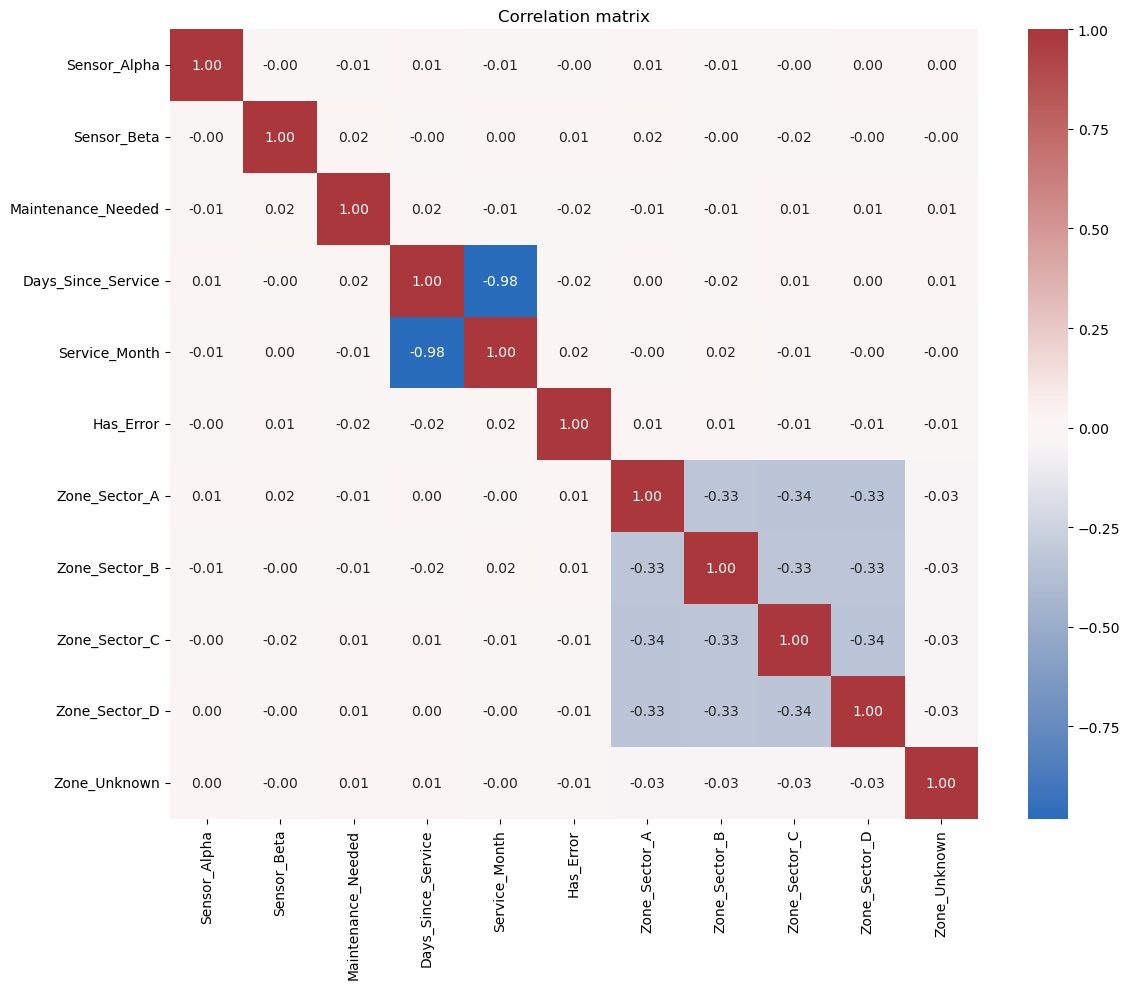

In [63]:
# TODO: Drop obvious irrelevant features
df.nunique()
#since ship_id and random_noise has 10000 unique values there are no predictive potential for these columns
df_dropped = df.drop(columns=['Ship_ID', 'Random_Noise'])
# TODO: Check correlation matrix (heatmap)
corr = df_dropped.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()



In [62]:
# TODO: Finalize the feature set (X) and target (y)
corr['Maintenance_Needed'].sort_values(ascending=False)
X = df_dropped.drop(columns=['Maintenance_Needed'])
y = df_dropped['Maintenance_Needed']

print(X.shape, y.shape)
X.head()

(10000, 13) (10000,)


,Sensor_Alpha,Sensor_Beta,Zone,Last_Service_Date,Error_Log,Days_Since_Service,Service_Month,Has_Error,Zone_Sector_A,Zone_Sector_B,Zone_Sector_C,Zone_Sector_D,Zone_Unknown
0,-0.132975,-0.381002,Sector_D,2024-05-15,Error: Pressure Drop,231,5,1,0,0,0,1,0
1,0.116916,4.034203,Sector_A,2024-08-31,Error: Pressure Drop,123,8,1,1,0,0,0,0
2,0.452986,-0.011467,Sector_D,2024-05-10,Unknown,236,5,0,0,0,0,1,0
3,-0.850787,1.101039,Sector_B,2024-07-04,Warning: High Temp,181,7,1,0,1,0,0,0
4,-0.180264,0.231352,Sector_D,2024-06-20,Warning: High Temp,195,6,1,0,0,0,1,0


---

## 7. Conclusion

You have now taken a raw, messy dataset and transformed it into a clean, structured set of features ready for machine learning. 




**Reflect:**
- Which preprocessing step do you think was most critical for this dataset?
  `data cleaning and standardization`
- How would the model performance likely change if you skipped standardization? `model will falsely attribute some relationship because the magnitude of the sensor data has a wide range, and error values has a lot of missing values, although error message does not correlate with maintenance`